# Construct biopsy tissue state model

This notebook shows the pipeline for projecting tissue state ontologies onto deconvolved bulk RNA-seq data and clustering biopsies. To see how the tissue state axis space was derived, see Tutorial #8.

# Import Packages

In [1]:
import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
import muon as mu
import re
import gseapy as gp
import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import scfo
import os

In [2]:
must_have_genes = [
'AIF1', 'ALDH1L1', 'ALDOC', 'AQP4', 'ATF3', 'BCL2A1', 'BIRC3', 'CCR2', 'CCR7', 'CD101', 'CD14', 'CD163', 'CD19', 'CD1C', 'CD2', 'CD28', 'CD3E', 'CD4',
'CD44', 'CD68', 'CD69', 'CD74', 'CD79A', 'CD79B', 'CD8A', 'CD8B', 'CDK4', 'CDKN2A', 'CEBPB', 'CHI3L1', 'CLDN5', 'CNP', 'COL1A2', 'CSF1R', 'CSPG4', 'CTLA4',
'CX3CR1', 'CXCR6', 'DCN', 'DCX', 'DPP10', 'EGFR', 'ESAM', 'FOXP3', 'GFAP', 'GJC2', 'GLUL', 'GNLY', 'GZMA', 'GZMB', 'GZMK', 'HEXB', 'ICOS', 'IL1B', 'IL3RA',
'ITGA1', 'ITGAE', 'ITGAM', 'ITGAX', 'JUNB', 'KLRD1', 'KLRF1', 'LAG3', 'LAMP3', 'MAG', 'MAP2', 'MARCO', 'MBP', 'MDM2', 'MERTK', 'MKI67', 'MOBP', 'MOG', 'MRC1',
'MS4A1', 'MSR1', 'MZB1', 'NCAM1', 'NES', 'NFIL3', 'OLIG1', 'OLIG2', 'P2RY12', 'PDCD1', 'PDGFRA', 'PDGFRB', 'PECAM1', 'PLP1', 'PPARG', 'PTPRC', 'PTPRZ1', 
'RBFOX3', 'S100B', 'SELL', 'SLC1A2', 'SLC1A3', 'SOX10', 'SOX2', 'SOX9', 'SYN1', 'SYT1', 'THBD', 'TIE1','TMEM119', 'TP53', 'VCAN', 'VIM', 'VWF',
]

In [3]:
def clr_transform(df, pseudocount=1e-6):
    """
    Perform centered log-ratio (CLR) transformation on a dataframe of proportions.

    Parameters
    ----------
    df : pandas.DataFrame
        Rows = biopsies (samples), columns = compositional features (cell types).
        Each row should sum to ~1.
    pseudocount : float
        Small value added to avoid log(0).

    Returns
    -------
    pandas.DataFrame
        CLR-transformed dataframe with same shape and labels.
    """
    # Add small pseudocount to avoid log(0)
    X = df + pseudocount

    # Compute geometric mean for each row
    gm = np.exp(np.log(X).mean(axis=1))

    # Compute CLR: log-ratio to geometric mean
    clr = np.log(X.div(gm, axis=0))

    return clr

def plot_pca_loadings(
    adata,
    loadings_key = 'PCs',
    n_components=5,
    top_features=None,
    figsize=(10, 4),
    sort_by_abs=True,
    palette="vlag",
    save=None
):
    """
    Plot PCA loadings for each PC in separate subplots.
    
    Parameters
    ----------
    adata : AnnData
        Must contain adata.varm["PCs"] (from sc.tl.pca).
    n_components : int
        Number of PCs to show.
    top_features : int or None
        Show top N features by absolute loading per PC (default: all).
    figsize : tuple
        (width, height) of the entire figure.
    sort_by_abs : bool
        Sort by absolute loading magnitude.
    palette : str
        Seaborn palette or colormap for bars.
    save : str or None
        Path to save figure (e.g., "pca_loadings_by_pc.svg").
    """

    # Extract loadings
    loadings = pd.DataFrame(
        adata.varm[loadings_key][:, :n_components],
        index=adata.var_names,
        columns=[f"PC{i+1}" for i in range(n_components)]
    )

    # Get variance explained if available
    var_exp = adata.uns.get("pca", {}).get("variance_ratio", None)
    if var_exp is not None:
        var_exp = np.round(100 * var_exp[:n_components], 1)
    else:
        var_exp = [None] * n_components

    # Create figure
    fig, axes = plt.subplots(
        1, n_components, figsize=(figsize[0] * n_components, figsize[1]),
        sharey=True
    )

    if n_components == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        pc = f"PC{i+1}"
        series = loadings[pc]

        # Select top features if requested
        if top_features is not None:
            if sort_by_abs:
                series = series.reindex(series.abs().sort_values(ascending=False).index)
            series = series.head(top_features)
        else:
            if sort_by_abs:
                series = series.reindex(series.abs().sort_values(ascending=False).index)

        # Plot horizontal bars
        sns.barplot(
            y=series.index,
            x=series.values,
            palette=palette,
            ax=ax
        )
        ax.axvline(0, color="black", lw=0.8)
        ax.set_title(
            f"{pc}" + (f"\n({var_exp[i]}% var)" if var_exp[i] is not None else "")
        )
        ax.set_xlabel("Loading weight")
        if i > 0:
            ax.set_ylabel("")

    plt.tight_layout()

    if save:
        plt.savefig(save, bbox_inches="tight", dpi=300)
    plt.show()


# Projecting scfo

In [4]:
disease = 'combined'

In [5]:
ontology = mu.read_h5mu('scFO_Models/scfo_mofa_'+disease+'.h5mu')

/Users/matthewwarren/anaconda3/envs/mmochi/lib/python3.8/site-packages/mudata/_core/mudata.py:491: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(


In [6]:
all_bulk_exp_ls = []
for cell_type in ['Mo_TAM', 'Mg_TAM', 'Tumor', 'Oligo', 'Neuron', 'T cell', 'Endothelial', 'Pericyte']:
    if cell_type in ['T cell']:
        cell_type_load = 'Lymphoid'
    else:
        cell_type_load = cell_type
        
    decon_counts = pd.read_csv('Data/Bulk_Cibersort/CIBERSORTx_Job13_output_GBM/CIBERSORTxHiRes_Job13_'+cell_type_load+'_Window40.txt', sep = '\t', index_col = 0)
    decon_counts_sub = decon_counts.dropna().T
    decon_counts_sub.index = decon_counts_sub.index.astype(str) + '~' + cell_type
    all_bulk_exp_ls.append(decon_counts_sub)
all_bulk_exp = pd.concat(all_bulk_exp_ls).fillna(0)
all_bulk_exp_adata = ad.AnnData(all_bulk_exp.copy())
all_bulk_exp_adata.obs['patient'] = all_bulk_exp_adata.obs.index.astype(str).str.split('~').str[0]
all_bulk_exp_adata.obs['cell_type'] = all_bulk_exp_adata.obs.index.astype(str).str.split('~').str[1]
all_bulk_exp_adata

AnnData object with n_obs × n_vars = 6968 × 999
    obs: 'patient', 'cell_type'

In [7]:
all_bulk_exp_adata.obs['cell_type'] = all_bulk_exp_adata.obs['cell_type'].astype(str)
scfo.project_ontology(
    adata=all_bulk_exp_adata,
    ontology=ontology,
    annotation_key="cell_type",
    score_key_added="ontology_scores",
    pval_key_added="ontology_pvals",
    method="permutation",
    n_iter=1000,
    inplace=True,
)

collapsed = scfo.collapse_projected_ontology_scores(
    adata=all_bulk_exp_adata,
    score_key="ontology_scores",
    output_key="ontology_scores_collapsed",
    agg="sum",
    store_sparse=False,
)

collapsed_wide_ls = []
for cell_type in ['Mo_TAM', 'Mg_TAM', 'Tumor', 'Oligo', 'Neuron', 'T cell', 'Endothelial', 'Pericyte']:
    collapsed_ct = collapsed.loc[collapsed.index.astype(str).str.contains(cell_type)].copy()
    collapsed_ct.columns = collapsed_ct.columns.astype(str) + '|' + cell_type
    collapsed_ct.index = collapsed_ct.index.astype(str).str.split('~').str[0]
    collapsed_wide_ls.append(collapsed_ct)
collapsed_wide = pd.concat(collapsed_wide_ls, axis = 1)
collapsed_wide

Permuting Mo_TAM...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Mg_TAM...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Tumor...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Oligo...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Neuron...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting T cell...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Endothelial...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Pericyte...:   0%|          | 0/1000 [00:00<?, ?it/s]

factor,Factor0|Mo_TAM,Factor1|Mo_TAM,Factor10|Mo_TAM,Factor11|Mo_TAM,Factor12|Mo_TAM,Factor13|Mo_TAM,Factor14|Mo_TAM,Factor15|Mo_TAM,Factor16|Mo_TAM,Factor17|Mo_TAM,...,Factor36|Pericyte,Factor37|Pericyte,Factor38|Pericyte,Factor39|Pericyte,Factor4|Pericyte,Factor5|Pericyte,Factor6|Pericyte,Factor7|Pericyte,Factor8|Pericyte,Factor9|Pericyte
141d1d6b-251b-48cf-abfd-bdbfdd0605b7,2.136560,2.760069,8.977730,1.253552,7.407580,5.276027,-4.662389,9.232232,-12.040124,-2.664621,...,-2.150231,2.357168,1.045207,3.087637,-1.187966,-8.324311,-1.294542,-4.884021,-16.400433,5.189711
45b03af8-f396-4c1b-809a-5e2aa7ce0769,2.226371,2.675366,9.087252,1.291117,7.395507,5.661600,-4.547899,9.200453,-12.176964,-2.604686,...,-2.372037,2.453706,0.509161,2.968357,-1.068345,-8.501538,-0.999665,-4.792700,-16.691175,4.991301
def5d534-0efd-450c-bde0-f69abbe48f7c,1.994490,1.930686,8.018936,0.575498,6.382248,3.762356,-3.891441,7.548397,-9.797454,-1.746445,...,-2.507204,2.519574,0.373564,2.998399,-1.275685,-8.786612,-0.940599,-4.896846,-16.733223,5.367060
5cafc8c0-a92c-407a-ad52-a2d9562c0bfa,2.277194,2.131722,8.537562,0.932256,7.026250,4.710133,-4.294423,8.581674,-11.005947,-2.324978,...,-2.229530,2.687020,0.516892,3.183450,-1.527794,-9.307668,-0.647476,-5.136879,-16.850149,5.497663
c99203bc-27cb-4af5-983f-46d87525a034,2.340972,2.996009,9.063262,1.347314,7.396782,5.749190,-4.874868,9.511005,-12.622250,-3.131351,...,-2.090220,2.415908,0.272275,2.673778,-0.487625,-7.980773,-1.021589,-3.814425,-16.244804,4.294879
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HF1469,1.816778,3.353274,8.853823,1.558936,7.495454,5.360665,-5.073204,9.431633,-12.596604,-2.779455,...,-2.494719,2.535450,0.207772,2.514096,-0.001369,-7.650605,-1.472767,-3.620600,-16.687269,3.837152
HF1058,1.812264,3.405552,8.894477,1.490610,7.502403,5.392573,-5.012436,9.311238,-12.557018,-2.842319,...,-3.081914,2.651460,0.123758,2.453614,-0.494150,-8.095196,-1.465909,-4.424775,-17.210279,4.222579
HF1078,1.871249,3.305521,8.825567,1.613819,7.523364,5.311705,-5.126027,9.570750,-12.623218,-2.803457,...,-2.750178,2.527325,0.004681,2.461236,-0.018986,-7.768980,-1.471417,-3.783271,-16.872896,3.864752
HF1097,1.938625,3.138571,8.928666,1.529468,7.559638,5.327567,-5.016006,9.551745,-12.465998,-2.818240,...,-2.735271,2.531189,0.148566,2.534423,-0.250525,-7.827838,-1.456909,-4.069151,-16.957762,4.138794


In [8]:
all_bulk_exp_ls = []
for cell_type in ['Mo_TAM', 'Mg_TAM', 'Tumor', 'Oligo', 'Neuron', 'T cell', 'Endothelial', 'Pericyte']:
    if cell_type in ['T cell']:
        cell_type_load = 'Lymphoid'
    else:
        cell_type_load = cell_type
        
    decon_counts = pd.read_csv('Data/Bulk_Cibersort/CIBERSORTx_Job12_output_LGG/CIBERSORTxHiRes_Job12_'+cell_type_load+'_Window36.txt', sep = '\t', index_col = 0)
    decon_counts_sub = decon_counts.dropna().T
    decon_counts_sub.index = decon_counts_sub.index.astype(str) + '~' + cell_type
    all_bulk_exp_ls.append(decon_counts_sub)
all_bulk_exp = pd.concat(all_bulk_exp_ls).fillna(0)
all_bulk_exp_adata_lgg = ad.AnnData(all_bulk_exp.copy())
all_bulk_exp_adata_lgg.obs['patient'] = all_bulk_exp_adata_lgg.obs.index.astype(str).str.split('~').str[0]
all_bulk_exp_adata_lgg.obs['cell_type'] = all_bulk_exp_adata_lgg.obs.index.astype(str).str.split('~').str[1]
all_bulk_exp_adata_lgg

AnnData object with n_obs × n_vars = 4192 × 999
    obs: 'patient', 'cell_type'

In [9]:
all_bulk_exp_adata_lgg.obs['cell_type'] = all_bulk_exp_adata_lgg.obs['cell_type'].astype(str)
scfo.project_ontology(
    adata=all_bulk_exp_adata_lgg,
    ontology=ontology,
    annotation_key="cell_type",
    score_key_added="ontology_scores",
    pval_key_added="ontology_pvals",
    method="permutation",
    n_iter=1000,
    inplace=True,
)

collapsed_lgg = scfo.collapse_projected_ontology_scores(
    adata=all_bulk_exp_adata_lgg,
    score_key="ontology_scores",
    output_key="ontology_scores_collapsed",
    agg="sum",
    store_sparse=False,
)

collapsed_wide_ls = []
for cell_type in ['Mo_TAM', 'Mg_TAM', 'Tumor', 'Oligo', 'Neuron', 'T cell', 'Endothelial', 'Pericyte']:
    collapsed_ct = collapsed_lgg.loc[collapsed_lgg.index.astype(str).str.contains(cell_type)].copy()
    collapsed_ct.columns = collapsed_ct.columns.astype(str) + '|' + cell_type
    collapsed_ct.index = collapsed_ct.index.astype(str).str.split('~').str[0]
    collapsed_wide_ls.append(collapsed_ct)
collapsed_wide_lgg = pd.concat(collapsed_wide_ls, axis = 1)
collapsed_wide_lgg

Permuting Mo_TAM...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Mg_TAM...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Tumor...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Oligo...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Neuron...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting T cell...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Endothelial...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Pericyte...:   0%|          | 0/1000 [00:00<?, ?it/s]

factor,Factor0|Mo_TAM,Factor1|Mo_TAM,Factor10|Mo_TAM,Factor11|Mo_TAM,Factor12|Mo_TAM,Factor13|Mo_TAM,Factor14|Mo_TAM,Factor15|Mo_TAM,Factor16|Mo_TAM,Factor17|Mo_TAM,...,Factor36|Pericyte,Factor37|Pericyte,Factor38|Pericyte,Factor39|Pericyte,Factor4|Pericyte,Factor5|Pericyte,Factor6|Pericyte,Factor7|Pericyte,Factor8|Pericyte,Factor9|Pericyte
CGGA_1309,1.236475,-0.900555,1.652309,-0.796678,1.403202,2.330966,1.133407,2.990859,-1.388945,-0.776517,...,-3.703406,3.421679,-0.515157,-2.872940,2.173170,1.015903,-5.031799,6.447580,-9.636127,-2.181346
CGGA_632,1.233387,-0.895146,1.649941,-0.802594,1.394532,2.332583,1.141687,2.984985,-1.385756,-0.775384,...,-3.916754,3.275755,-0.516850,-2.796349,2.108411,1.084200,-4.614139,6.751142,-9.617086,-2.165806
CGGA_1169,1.248368,-0.900647,1.636544,-0.813045,1.426477,2.292439,1.117203,3.006660,-1.374951,-0.746283,...,-3.660793,3.435836,-0.515277,-2.857066,2.187155,1.009733,-5.082371,6.437345,-9.632126,-2.188021
CGGA_898,1.234799,-0.888121,1.638510,-0.825274,1.397391,2.318579,1.146839,2.984898,-1.373090,-0.753098,...,-3.627719,3.461576,-0.494523,-2.923147,2.151738,0.965745,-4.726812,6.101276,-9.353580,-2.042991
CGGA_1621,1.233074,-0.894583,1.653515,-0.802674,1.392800,2.338068,1.147765,2.980170,-1.387750,-0.772507,...,-3.716574,3.430603,-0.514642,-2.898883,2.178328,1.026537,-4.992284,6.401728,-9.611020,-2.185631
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GLSS-HK-0004,1.229313,-0.885095,1.641901,-0.819405,1.384276,2.329467,1.155760,2.977409,-1.375730,-0.765527,...,-3.648662,3.381035,-0.467835,-2.845176,2.077966,0.879961,-4.157585,6.031286,-9.066065,-1.996645
TCGA-TM-A7CF,1.232565,-0.894236,1.654923,-0.802503,1.391981,2.339853,1.149674,2.978051,-1.387872,-0.773286,...,-3.629930,3.428049,-0.474251,-2.934487,2.103984,0.892462,-4.274233,5.884871,-9.077565,-1.907614
GLSS-SF-0014,1.249146,-0.907522,1.654566,-0.793807,1.426284,2.314451,1.122895,2.999188,-1.390816,-0.754399,...,-3.644829,3.450643,-0.501865,-2.929825,2.166440,1.000977,-4.863476,6.177783,-9.461589,-2.126245
TCGA-TQ-A8XE,1.240454,-0.902525,1.657238,-0.800042,1.409405,2.335231,1.136924,2.988441,-1.392589,-0.762588,...,-3.542231,3.476249,-0.471096,-2.945215,2.116066,0.870703,-4.401519,5.751169,-9.047707,-1.930009


In [10]:
collapsed_all = pd.concat([collapsed_wide, collapsed_wide_lgg])

In [11]:
collapsed_all.to_csv('Data/Tissue_States_Scores_Biopsies/bulk_scfo_'+disease+'.csv')

# Projecting tissue states

In [12]:
import muon as mu

In [13]:
comp_exp_mofa_scores = pd.read_csv('Data/Tissue_States_Meta_MOFA_Models/scfo_exp_comp_integration_'+disease+'_scores.csv', index_col = 0)
comp_exp_mofa_weights = pd.read_csv('Data/Tissue_States_Meta_MOFA_Models/scfo_exp_comp_integration_'+disease+'_weights.csv', index_col = 0)

comp_exp_mofa_weights_sub = comp_exp_mofa_weights[comp_exp_mofa_weights.abs().sum()[comp_exp_mofa_weights.abs().sum() > 1e-8].index]
comp_exp_mofa_scores_sub = comp_exp_mofa_scores[comp_exp_mofa_scores.abs().sum()[comp_exp_mofa_scores.abs().sum() > 1e-8].index]

meta_mofa_scores = pd.read_csv('Data/Tissue_States_Meta_MOFA_Models/scfo_exp_meta_mofa_'+disease+'_scores.csv', index_col = 0)
meta_mofa_weights = pd.read_csv('Data/Tissue_States_Meta_MOFA_Models/scfo_exp_meta_mofa_'+disease+'_weights.csv', index_col = 0)

meta_mofa_weights_sub = meta_mofa_weights[meta_mofa_weights.abs().sum()[meta_mofa_weights.abs().sum() > 1e-8].index]
meta_mofa_scores_sub = meta_mofa_scores[meta_mofa_scores.abs().sum()[meta_mofa_scores.abs().sum() > 1e-8].index]

In [14]:
mean_scores_bulk = pd.read_csv('Data/Tissue_States_Scores_Biopsies/bulk_scfo_'+disease+'.csv', index_col = 0)
mean_scores_bulk.columns = mean_scores_bulk.columns.astype(str) + '::mean'

In [15]:
meta_scores_proj_bulk = mean_scores_bulk.fillna(0) @ meta_mofa_weights_sub.loc[mean_scores_bulk.columns]
meta_scores_proj_bulk_z = (meta_scores_proj_bulk - meta_scores_proj_bulk.mean()) / meta_scores_proj_bulk.std()

In [16]:
fractions_bulk = pd.read_csv('Data/Bulk_Cibersort/CIBERSORTx_Job13_output_GBM/CIBERSORTxGEP_Job13_Fractions.txt', sep = '\t', index_col = 0).drop(columns = ['P-value', 'Correlation', 'RMSE'])
fractions_bulk_clr = clr_transform(fractions_bulk)
fractions_bulk_clr_z = (fractions_bulk_clr - fractions_bulk_clr.mean()) / fractions_bulk_clr.std()

In [17]:
fractions_bulk_lgg = pd.read_csv('Data/Bulk_Cibersort/CIBERSORTx_Job12_output_LGG/CIBERSORTxGEP_Job12_Fractions.txt', sep = '\t', index_col = 0).drop(columns = ['P-value', 'Correlation', 'RMSE'])
fractions_bulk_clr_lgg = clr_transform(fractions_bulk_lgg)
fractions_bulk_clr_z_lgg = (fractions_bulk_clr_lgg - fractions_bulk_clr_lgg.mean()) / fractions_bulk_clr_lgg.std()

In [18]:
fractions_all_tr = pd.concat([fractions_bulk_clr_z, fractions_bulk_clr_z_lgg]).fillna(0)

In [19]:
bulk_all = pd.concat([
    fractions_all_tr,
    meta_scores_proj_bulk_z
], axis = 1)

In [20]:
bulk_all_adata = ad.AnnData(bulk_all.copy())

In [21]:
tissue_states_ontology = scfo.make_ontology(comp_exp_mofa_weights_sub)

In [22]:
scfo.project_ontology(
    adata = bulk_all_adata,
    ontology = tissue_states_ontology,
    method = 'permutation',
    n_iter = 100000
)

Permuting globally...:   0%|          | 0/100000 [00:00<?, ?it/s]

In [23]:
tissue_states_ontology

MuData object with n_obs × n_vars = 8 × 31
  obs:	'FactorName', 'Classification', 'Number', 'FactorType'
  uns:	'gene_names', 'factor_type', 'modality_names'
  1 modality
    weights:	8 x 31

In [24]:
tissue_states_bulk = pd.DataFrame(bulk_all_adata.obsm['scfo_scores'].todense(), index = bulk_all_adata.obs.index, columns = tissue_states_ontology.obs.index)

In [25]:
tissue_states_bulk.to_csv('Data/Tissue_States_Scores_Biopsies/TS_scores_Bulk_'+disease+'.csv')

# Integrated model/clustering

In [26]:
tissue_states_bulk = pd.read_csv('Data/Tissue_States_Scores_Biopsies/TS_scores_Bulk_'+disease+'.csv', index_col = 0)

In [27]:
tissue_states_sc = pd.read_csv('Data/Tissue_States_Scores_Biopsies/TS_scores_SC_'+disease+'.csv', index_col = 0)

In [28]:
tissue_state_scores_z = pd.concat([tissue_states_sc/tissue_states_sc.std(), tissue_states_bulk/tissue_states_bulk.std()])

In [29]:
adata_cluster = ad.AnnData(tissue_state_scores_z.copy())
adata_cluster.obsm['X_pca'] = adata_cluster.X.copy()

In [30]:
metadata_all = pd.read_csv('Data/Single_Cell_Biopsies/biopsy_metadata_'+disease+'.csv', index_col = 0)
metadata = metadata_all[(metadata_all['Lineage enrichment'] == 'no')].copy()

In [31]:
adata_cluster.obs['group'] = 'bulk'
adata_cluster.obs.loc[metadata.index, 'group'] = metadata['Cells vs Nuclei'].astype(str)

In [32]:
fractions_bulk = pd.read_csv('Data/Bulk_Cibersort/CIBERSORTx_Job13_output_GBM/CIBERSORTxGEP_Job13_Fractions.txt', sep = '\t', index_col = 0).drop(columns = ['P-value', 'Correlation', 'RMSE'])
fractions_bulk_clr = clr_transform(fractions_bulk)
fractions_bulk_clr_z = (fractions_bulk_clr - fractions_bulk_clr.mean()) / fractions_bulk_clr.std()

In [33]:
fractions_bulk_lgg = pd.read_csv('Data/Bulk_Cibersort/CIBERSORTx_Job12_output_LGG/CIBERSORTxGEP_Job12_Fractions.txt', sep = '\t', index_col = 0).drop(columns = ['P-value', 'Correlation', 'RMSE'])
fractions_bulk_clr_lgg = clr_transform(fractions_bulk_lgg)
fractions_bulk_clr_z_lgg = (fractions_bulk_clr_lgg - fractions_bulk_clr_lgg.mean()) / fractions_bulk_clr_lgg.std()

In [34]:
import scanpy.external as sce
sce.pp.harmony_integrate(
    adata_cluster,
    'group',
    max_iter_harmony=100,
)

2026-04-23 17:58:27,180 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-04-23 17:58:27,566 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-04-23 17:58:27,573 - harmonypy - INFO - Iteration 1 of 100
2026-04-23 17:58:27,754 - harmonypy - INFO - Iteration 2 of 100
2026-04-23 17:58:27,937 - harmonypy - INFO - Iteration 3 of 100
2026-04-23 17:58:28,111 - harmonypy - INFO - Iteration 4 of 100
2026-04-23 17:58:28,313 - harmonypy - INFO - Iteration 5 of 100
2026-04-23 17:58:28,494 - harmonypy - INFO - Iteration 6 of 100
2026-04-23 17:58:28,681 - harmonypy - INFO - Iteration 7 of 100
2026-04-23 17:58:28,895 - harmonypy - INFO - Iteration 8 of 100
2026-04-23 17:58:29,081 - harmonypy - INFO - Converged after 8 iterations


In [35]:
sc.pp.neighbors(adata_cluster, use_rep = 'X_pca_harmony')

In [36]:
sc.tl.umap(
    adata_cluster, 
    n_components = 3
)
for resolution in [0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1, 2]:
    sc.tl.leiden(
        adata_cluster, 
        resolution = resolution,
        key_added = 'leiden_'+str(resolution)
    )

In [37]:
adata_cluster

AnnData object with n_obs × n_vars = 1989 × 8
    obs: 'group', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'leiden_0.75', 'leiden_1', 'leiden_2'
    uns: 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    obsp: 'distances', 'connectivities'

/Users/matthewwarren/anaconda3/envs/mmochi/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/matthewwarren/anaconda3/envs/mmochi/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


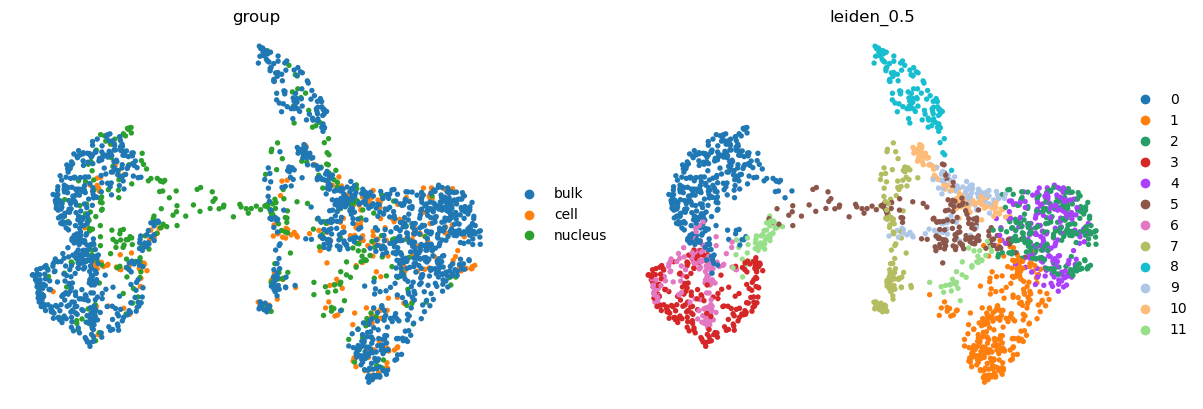

In [38]:
sc.pl.umap(adata_cluster, color = ['group', 'leiden_0.5'], frameon = False, show = True)

In [39]:
adata_cluster.write('Data/Tissue_States_Scores_Biopsies/adata_cluster_'+disease+'.h5ad')

In [40]:
umap_df = pd.DataFrame(adata_cluster.obsm['X_umap'], index = adata_cluster.obs.index)
umap_df.columns = 'UMAP_'+umap_df.columns.astype(str)

In [41]:
tissue_states_harmony = pd.DataFrame(adata_cluster.obsm['X_pca_harmony'], index = adata_cluster.obs.index, columns = adata_cluster.var_names)

In [42]:
adata_cluster.obs['disease_group'] = 'Unk'
adata_cluster.obs.loc[metadata.index, 'disease_group'] = metadata['disease_group'].astype(str)
adata_cluster.obs.loc[fractions_bulk_clr_z_lgg.index, 'disease_group'] = 'LGG'
adata_cluster.obs.loc[fractions_bulk_clr_z.index, 'disease_group'] = 'GBM'

In [43]:
adata_harmony = ad.AnnData(tissue_states_harmony.copy())
adata_harmony.obs = adata_cluster.obs.copy()

In [44]:
adata_harmony.obsm['X_umap'] = adata_cluster.obsm['X_umap'].copy()

In [45]:
sc.pp.neighbors(adata_harmony, use_rep = 'X')

In [46]:
sc.tl.diffmap(adata_harmony)

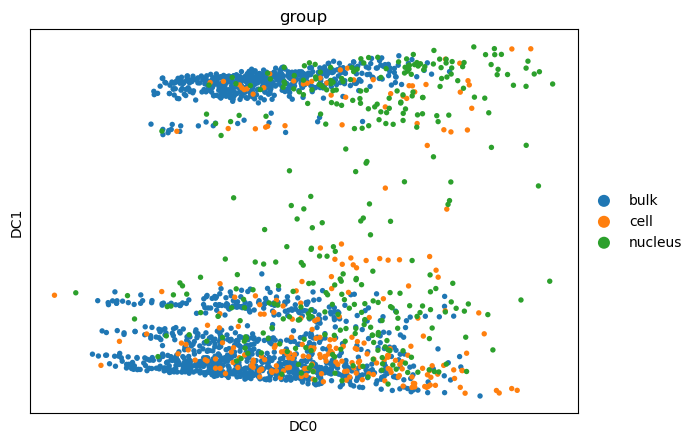

In [47]:
sc.pl.scatter(
    adata_harmony,
    basis="diffmap",
    color=["group"],
    components=[0,1],
)

In [48]:
root_ixs = adata_harmony[adata_harmony.obs.disease_group == 'NB'].obsm["X_diffmap"][:, 1].argmax()
#root_ixs = adata_harmony.obsm["X_diffmap"][:, 1].argmax()
adata_harmony.uns["iroot"] = root_ixs

In [49]:
sc.tl.dpt(adata_harmony)

/Users/matthewwarren/anaconda3/envs/mmochi/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


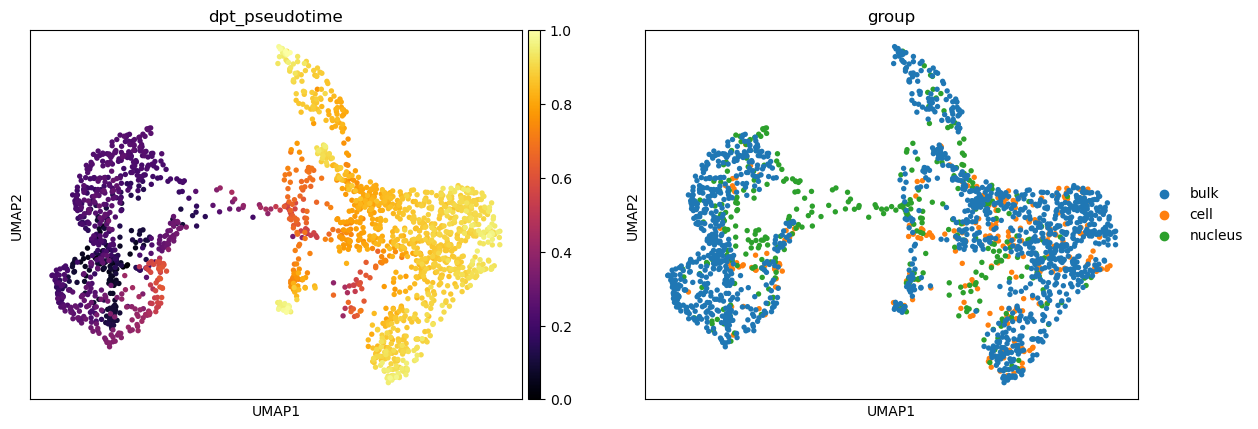

In [50]:
sc.pl.umap(adata_harmony, color = ['dpt_pseudotime', "group"], cmap = 'inferno')

In [51]:
state_model_obs = pd.concat([
    umap_df,
    adata_cluster.obs[adata_cluster.obs.columns[adata_cluster.obs.columns.astype(str).str.contains('leiden')]].astype(str),
    adata_harmony.obs[['dpt_pseudotime']]
], axis = 1)

In [52]:
state_model_obs.to_csv('Data/Tissue_States_Scores_Biopsies/state_model_obs_'+disease+'.csv')

In [53]:
tissue_states_harmony.to_csv('Data/Tissue_States_Scores_Biopsies/TS_scores_harmony_'+disease+'.csv')

# Constructing biopsy objects

In [54]:
disease = 'combined'

In [55]:
### scFO scores

mean_scores_all = pd.read_csv('Data/Single_Cell_Biopsies/biopsy_factor_scores_mean_'+disease+'.csv', index_col = 0)
std_scores_all = pd.read_csv('Data/Single_Cell_Biopsies/biopsy_factor_scores_std_'+disease+'.csv', index_col = 0)
mean_scores_bulk = pd.read_csv('Data/Tissue_States_Scores_Biopsies/bulk_scfo_'+disease+'.csv', index_col = 0)

all_scfo_mean = pd.concat([mean_scores_all, mean_scores_bulk])
all_scfo_std = std_scores_all.copy()

In [56]:
### Fractions

fractions_bulk = pd.read_csv('Data/Bulk_Cibersort/CIBERSORTx_Job13_output_GBM/CIBERSORTxGEP_Job13_Fractions.txt', sep = '\t', index_col = 0).drop(columns = ['P-value', 'Correlation', 'RMSE'])
fractions_bulk_clr = clr_transform(fractions_bulk)
fractions_bulk_clr_z = (fractions_bulk_clr - fractions_bulk_clr.mean()) / fractions_bulk_clr.std()

fractions_bulk_lgg = pd.read_csv('Data/Bulk_Cibersort/CIBERSORTx_Job12_output_LGG/CIBERSORTxGEP_Job12_Fractions.txt', sep = '\t', index_col = 0).drop(columns = ['P-value', 'Correlation', 'RMSE'])
fractions_bulk_clr_lgg = clr_transform(fractions_bulk_lgg)
fractions_bulk_clr_z_lgg = (fractions_bulk_clr_lgg - fractions_bulk_clr_lgg.mean()) / fractions_bulk_clr_lgg.std()

single_cell_fractions = pd.read_csv('Data/Single_Cell_Biopsies/biopsy_composition_'+disease+'.csv', index_col = 0)
single_cell_fractions['Lymphoid'] = single_cell_fractions['T cell'] + single_cell_fractions.Non_T_Lymphocyte
single_cell_fractions.drop(columns = [
    'T cell', 'Non_T_Lymphocyte', 
], inplace = True)

metadata_all = pd.read_csv('Data/Single_Cell_Biopsies/biopsy_metadata_'+disease+'.csv', index_col = 0)
metadata = metadata_all[
    (metadata_all['Lineage enrichment'] == 'no')
].copy()
metadata_cells = metadata[metadata['Cells vs Nuclei'] == 'cell'].copy()
metadata_nuclei = metadata[metadata['Cells vs Nuclei'] == 'nucleus'].copy()

fractions_main_cells = single_cell_fractions.loc[metadata_cells.index].copy()
fractions_main_cells_clr = clr_transform(fractions_main_cells)
fractions_main_cells_clr_z = (fractions_main_cells_clr - fractions_main_cells_clr.mean()) / fractions_main_cells_clr.std()

fractions_main_nuclei = single_cell_fractions.loc[metadata_nuclei.index].copy()
fractions_main_nuclei_clr = clr_transform(fractions_main_nuclei)
fractions_main_nuclei_clr_z = (fractions_main_nuclei_clr - fractions_main_nuclei_clr.mean()) / fractions_main_nuclei_clr.std()

fractions_main = pd.concat([fractions_main_cells_clr_z, fractions_main_nuclei_clr_z])

all_fractions = pd.concat([
    fractions_main,
    fractions_bulk_clr_z,
    fractions_bulk_clr_z_lgg
])

all_fractions_raw = pd.concat([
    single_cell_fractions,
    fractions_bulk,
    fractions_bulk_lgg
])

In [57]:
### Tissue state scores

tissue_states_bulk = pd.read_csv('Data/Tissue_States_Scores_Biopsies/TS_scores_Bulk_'+disease+'.csv', index_col = 0)
tissue_states_sc = pd.read_csv('Data/Tissue_States_Scores_Biopsies/TS_scores_SC_'+disease+'.csv', index_col = 0)
all_ts = pd.concat([tissue_states_sc/tissue_states_sc.std(), tissue_states_bulk/tissue_states_bulk.std()])

In [58]:
### Survival scores

survival_scores_sc = pd.read_csv('Data/Tissue_States_Scores_Biopsies/Survival_scores_'+disease+'.csv', index_col = 0)

surv_weights = pd.read_csv('Data/scFO_Priors/all_pathway_profile.csv', index_col = 0)
surv_weights['metric'] = np.where(surv_weights.index.astype(str).str.contains('mean'), 'mean', 'std')
surv_weights.index = surv_weights.index.astype(str).str.replace('mean', '')
surv_weights.index = surv_weights.index.astype(str).str.replace('std', '')
surv_weights.index = surv_weights.index.astype(str).str.replace('__', '|', regex = False)
surv_weights.index = surv_weights.index.astype(str) + '::' + surv_weights.metric.astype(str)
surv_weights.drop(columns = 'metric', inplace = True)

mean_scores_bulk_surv = mean_scores_bulk.copy()
mean_scores_bulk_surv.columns = mean_scores_bulk_surv.columns.astype(str) + '::mean'

common_indices = list(set(surv_weights.index) & set(mean_scores_bulk_surv.columns))
surv_scores = mean_scores_bulk_surv[common_indices].fillna(0) @ surv_weights.loc[common_indices]
surv_scores_z = (surv_scores - surv_scores.mean()) / surv_scores.std()
surv_scores_z.to_csv('Data/Tissue_States_Scores_Biopsies/Survival_scores_'+disease+'.csv')
all_survival = pd.concat([survival_scores_sc, surv_scores_z])

In [59]:
state_model_obs = pd.read_csv('Data/Tissue_States_Scores_Biopsies/state_model_obs_'+disease+'.csv', index_col = 0)
tissue_states_harmony = pd.read_csv('Data/Tissue_States_Scores_Biopsies/TS_scores_harmony_'+disease+'.csv', index_col = 0)

In [61]:
### Tumor CNV scores

tumor_cnv_scores_mean_gbm = pd.read_csv('Data/Tissue_States_Scores_Biopsies/all_cnv_profile_grouped_mean_gbm.csv', index_col = 0)
tumor_cnv_scores_mean_lgg = pd.read_csv('Data/Tissue_States_Scores_Biopsies/all_cnv_profile_grouped_mean_lgg.csv', index_col = 0)
tumor_cnv_scores_mean_all = pd.concat([tumor_cnv_scores_mean_gbm, tumor_cnv_scores_mean_lgg])
tumor_cnv_scores_mean = tumor_cnv_scores_mean_all[tumor_cnv_scores_mean_all.final_annotation_fine == 'Tumor'].drop(columns = 'final_annotation_fine').set_index('Sample_Study')

tumor_cnv_scores_std_gbm = pd.read_csv('Data/Tissue_States_Scores_Biopsies/all_cnv_profile_grouped_std_gbm.csv', index_col = 0)
tumor_cnv_scores_std_lgg = pd.read_csv('Data/Tissue_States_Scores_Biopsies/all_cnv_profile_grouped_std_lgg.csv', index_col = 0)
tumor_cnv_scores_std_all = pd.concat([tumor_cnv_scores_std_gbm, tumor_cnv_scores_std_lgg])
tumor_cnv_scores_std = tumor_cnv_scores_std_all[tumor_cnv_scores_std_all.final_annotation_fine == 'Tumor'].drop(columns = 'final_annotation_fine').set_index('Sample_Study')

In [62]:
### Tumor signature scores

tumor_sigs_mean = pd.read_csv('Data/Tissue_States_Scores_Biopsies/tumor_signature_scores_grouped_mean.csv', index_col = 0).drop(columns = 'final_annotation_fine').set_index('Sample_Study')
tumor_sigs_std = pd.read_csv('Data/Tissue_States_Scores_Biopsies/tumor_signature_scores_grouped_std.csv', index_col = 0).drop(columns = 'final_annotation_fine').set_index('Sample_Study')

In [63]:
metadata_master = pd.read_csv('Data/Master_Metadata.csv', index_col = 0)

In [64]:
main_biopsies = tissue_states_harmony.index

In [65]:
ts_adata = ad.AnnData(all_ts.loc[main_biopsies].copy())
ts_adata.layers['harmonized'] = tissue_states_harmony.loc[main_biopsies].copy()

In [66]:
fraction_adata = ad.AnnData(all_fractions_raw.loc[main_biopsies].copy())
fraction_adata.layers['CLR'] = all_fractions.loc[main_biopsies].copy()

In [67]:
scfo_adata = ad.AnnData(all_scfo_mean.loc[main_biopsies].copy())
scfo_adata.layers['stdev'] = all_scfo_std.reindex(all_scfo_mean.index).loc[main_biopsies].copy()

In [68]:
survival_adata = ad.AnnData(all_survival.loc[main_biopsies].copy())

In [69]:
tumor_cnv_adata = ad.AnnData(tumor_cnv_scores_mean.reindex(main_biopsies).copy())
tumor_cnv_adata.layers['stdev'] = tumor_cnv_scores_std.reindex(main_biopsies).copy()

In [70]:
tumor_sigs_adata = ad.AnnData(tumor_sigs_mean.reindex(main_biopsies).copy())
tumor_sigs_adata.layers['stdev'] = tumor_sigs_std.reindex(main_biopsies).copy()

In [71]:
final_adata_dict = {
    'tissue_states': ts_adata.copy(),
    'fractions': fraction_adata.copy(),
    'scfo': scfo_adata.copy(),
    'survival_scores': survival_adata.copy(),
    'tumor_cnv': tumor_cnv_adata.copy(),
    'tumor_signatures': tumor_sigs_adata.copy()
}

In [72]:
final_adata_dict

{'tissue_states': AnnData object with n_obs × n_vars = 1989 × 8
     layers: 'harmonized',
 'fractions': AnnData object with n_obs × n_vars = 1989 × 10
     layers: 'CLR',
 'scfo': AnnData object with n_obs × n_vars = 1989 × 440
     layers: 'stdev',
 'survival_scores': AnnData object with n_obs × n_vars = 1989 × 5,
 'tumor_cnv': AnnData object with n_obs × n_vars = 1989 × 23
     layers: 'stdev',
 'tumor_signatures': AnnData object with n_obs × n_vars = 1989 × 25
     layers: 'stdev'}

In [73]:
pb_main = sc.read_h5ad('Data/Single_Cell_Pseudobulk/pb_GBM_main.h5ad')
pb_main.obs[['patient', 'cell_type']] = pb_main.obs[['Sample_Study', 'final_annotation_fine']]

pb_val = sc.read_h5ad('Data/Single_Cell_Pseudobulk/pb_GBM_val.h5ad')
pb_val.obs[['patient', 'cell_type']] = pb_val.obs[['Sample_Study', 'final_annotation_fine']]

pb_LGG = sc.read_h5ad('Data/Single_Cell_Pseudobulk/pb_LGG.h5ad')
pb_LGG.obs[['patient', 'cell_type']] = pb_LGG.obs[['Sample_Study', 'final_annotation_fine']]

pb_NB = sc.read_h5ad('Data/Single_Cell_Pseudobulk/pb_NB.h5ad')
pb_NB.obs[['patient', 'cell_type']] = pb_NB.obs[['Sample_Study', 'final_annotation_fine']]

all_mofa_weights = pd.read_csv('Data/scFO_Input/mofa_weights_'+disease+'.csv', index_col = 0).fillna(0)

sc.pp.normalize_total(pb_main, target_sum = 1e6)
sc.pp.normalize_total(pb_val, target_sum = 1e6)
sc.pp.normalize_total(pb_LGG, target_sum = 1e6)
sc.pp.normalize_total(pb_NB, target_sum = 1e6)

all_pb = ad.concat([
    all_bulk_exp_adata,
    all_bulk_exp_adata_lgg,
    pb_main,
    pb_val,
    pb_LGG,
    pb_NB
], join = 'outer')

sc.pp.log1p(all_pb)

In [74]:
for ct in tqdm.tqdm(all_pb.obs.cell_type.unique()):
    all_pb_ct = all_pb[all_pb.obs.cell_type == ct]
    exp_ct = all_pb_ct.to_df()
    exp_ct['patient'] = all_pb_ct.obs['patient']
    exp_ct.set_index('patient', inplace = True)
    all_pb_min = ad.AnnData(
        exp_ct.reindex(main_biopsies).fillna(0).loc[main_biopsies, all_mofa_weights.index].copy()
    )
    final_adata_dict['genes_'+ct] = all_pb_min.copy()

100%|███████████████████████████████████████████| 11/11 [00:08<00:00,  1.32it/s]


In [75]:
final_adata_dict

{'tissue_states': AnnData object with n_obs × n_vars = 1989 × 8
     layers: 'harmonized',
 'fractions': AnnData object with n_obs × n_vars = 1989 × 10
     layers: 'CLR',
 'scfo': AnnData object with n_obs × n_vars = 1989 × 440
     layers: 'stdev',
 'survival_scores': AnnData object with n_obs × n_vars = 1989 × 5,
 'tumor_cnv': AnnData object with n_obs × n_vars = 1989 × 23
     layers: 'stdev',
 'tumor_signatures': AnnData object with n_obs × n_vars = 1989 × 25
     layers: 'stdev',
 'genes_Mo_TAM': AnnData object with n_obs × n_vars = 1989 × 6352,
 'genes_Mg_TAM': AnnData object with n_obs × n_vars = 1989 × 6352,
 'genes_Tumor': AnnData object with n_obs × n_vars = 1989 × 6352,
 'genes_Oligo': AnnData object with n_obs × n_vars = 1989 × 6352,
 'genes_Neuron': AnnData object with n_obs × n_vars = 1989 × 6352,
 'genes_T cell': AnnData object with n_obs × n_vars = 1989 × 6352,
 'genes_Endothelial': AnnData object with n_obs × n_vars = 1989 × 6352,
 'genes_Pericyte': AnnData object wit

In [76]:
final_mdata = mu.MuData(final_adata_dict)
final_mdata.obs = pd.concat([
    metadata_master.loc[main_biopsies],
    state_model_obs.loc[main_biopsies, ['leiden_0.1',	
                                        'leiden_0.2',	
                                        'leiden_0.3',	
                                        'leiden_0.4',	
                                        'leiden_0.5',	
                                        'leiden_0.75',	
                                        'leiden_1',	
                                        'leiden_2',	
                                        'dpt_pseudotime']]
], axis = 1)
final_mdata.obsm['X_umap'] = state_model_obs.loc[main_biopsies, ['UMAP_0', 'UMAP_1', 'UMAP_2']].copy()

/Users/matthewwarren/anaconda3/envs/mmochi/lib/python3.8/site-packages/mudata/_core/mudata.py:491: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(


In [77]:
final_mdata.obs = final_mdata.obs.astype(str)
final_mdata.obs['dpt_pseudotime'] = final_mdata.obs['dpt_pseudotime'].astype(float)

In [78]:
final_mdata.write_h5mu('scFO_Models/biopsy_tissue_states_'+disease+'.h5mu')

/Users/matthewwarren/anaconda3/envs/mmochi/lib/python3.8/site-packages/mudata/_core/mudata.py:491: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(


In [79]:
final_mdata

MuData object with n_obs × n_vars = 1989 × 70383
  obs:	'Cells vs Nuclei', 'Study', 'Grade', 'Path_diagnosis', 'IDH', 'TERT', 'EGFR_mut', 'ATRX_mut', 'MGMT', 'RT', 'Steroids', '1p_19q', 'Chemo', 'Status', 'Age', 'Sex', 'Lobe', 'Laterality', 'edge_v_core', 'OS_mo', 'Event', 'TTR', 'disease_group', 'Chemo_updated', 'Chemo_alk_tmz', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'leiden_0.75', 'leiden_1', 'leiden_2', 'dpt_pseudotime'
  obsm:	'X_umap'
  17 modalities
    tissue_states:	1989 x 8
      layers:	'harmonized'
    fractions:	1989 x 10
      layers:	'CLR'
    scfo:	1989 x 440
      layers:	'stdev'
    survival_scores:	1989 x 5
    tumor_cnv:	1989 x 23
      layers:	'stdev'
    tumor_signatures:	1989 x 25
      layers:	'stdev'
    genes_Mo_TAM:	1989 x 6352
    genes_Mg_TAM:	1989 x 6352
    genes_Tumor:	1989 x 6352
    genes_Oligo:	1989 x 6352
    genes_Neuron:	1989 x 6352
    genes_T cell:	1989 x 6352
    genes_Endothelial:	1989 x 6352
    genes_Pericyte:	1989 x 6352
    genes_Non_Mac_Myelocyte:	1989 x 6352
    genes_Non_T_Lymphocyte:	1989 x 6352
    genes_Astrocyte:	1989 x 6352